# 02 – Exploratory Data Analysis

## Project Overview

In this notebook, I explore the cleaned LinkedIn job postings dataset to better understand the relationships between job characteristics and salary.

The objectives of this analysis are to:

- Understand the distribution of salaries
- Explore relationships between salary and categorical features
- Identify trends across job titles, locations, and experience levels
- Generate insights that will guide feature engineering and model development

The findings from this notebook will inform the machine learning models built later in the project.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)

In [2]:
# Load clean dataset
project_root = Path.cwd().parent

processed_dir = project_root / "data" / "processed"

df = pd.read_csv(processed_dir / "clean_jobs.csv")

df.head()

,title,location,formatted_work_type,formatted_experience_level,company_name,views,normalized_salary
0,Marketing Coordinator,"Princeton, NJ",Full-time,Unknown,Corcoran Sawyer Smith,20.0,38480.0
1,Mental Health Therapist/Counselor,"Fort Collins, CO",Full-time,Unknown,Unknown,1.0,83200.0
2,Assitant Restaurant Manager,"Cincinnati, OH",Full-time,Unknown,The National Exemplar,8.0,55000.0
3,Senior Elder Law / Trusts and Estates Associat...,"New Hyde Park, NY",Full-time,Unknown,"Abrams Fensterman, LLP",16.0,157500.0
4,Service Technician,"Burlington, IA",Full-time,Unknown,Unknown,3.0,70000.0


## Dataset Overview

Before creating visualizations, I first check the size and structure of the cleaned dataset.

In [3]:
df.shape

(35560, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35560 entries, 0 to 35559
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   title                       35560 non-null  str    
 1   location                    35560 non-null  str    
 2   formatted_work_type         35560 non-null  str    
 3   formatted_experience_level  35560 non-null  str    
 4   company_name                35560 non-null  str    
 5   views                       35560 non-null  float64
 6   normalized_salary           35560 non-null  float64
dtypes: float64(2), str(5)
memory usage: 1.9 MB


In [5]:
df.describe()

,views,normalized_salary
count,35560.000000,35560.000000
mean,19.466451,96728.356510
std,123.485464,60917.121679
min,1.000000,20000.000000
25%,3.000000,52340.600000
50%,5.000000,82500.000000
75%,10.000000,125000.000000
max,9975.000000,960000.000000


## Salary Distribution

I begin by examining the distribution of salaries to understand the range, spread, and potential outliers in the dataset.

Understanding the target variable is an important first step before developing machine learning models.

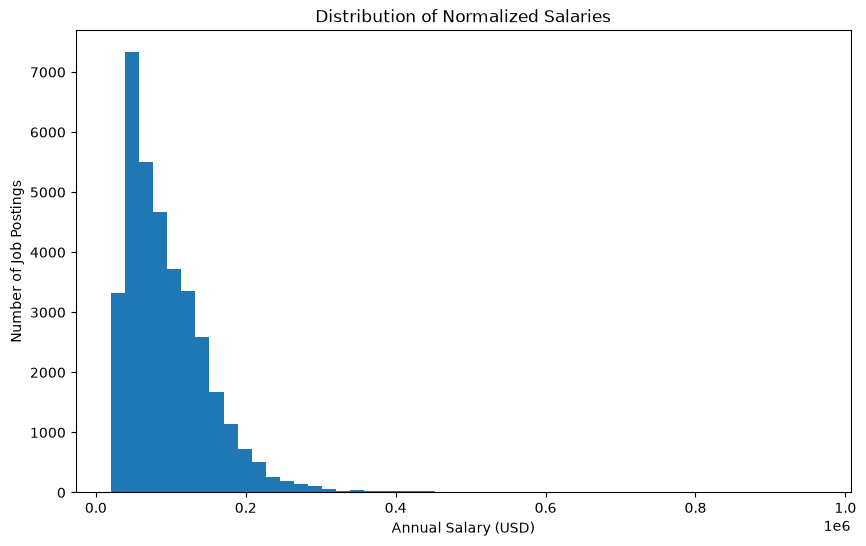

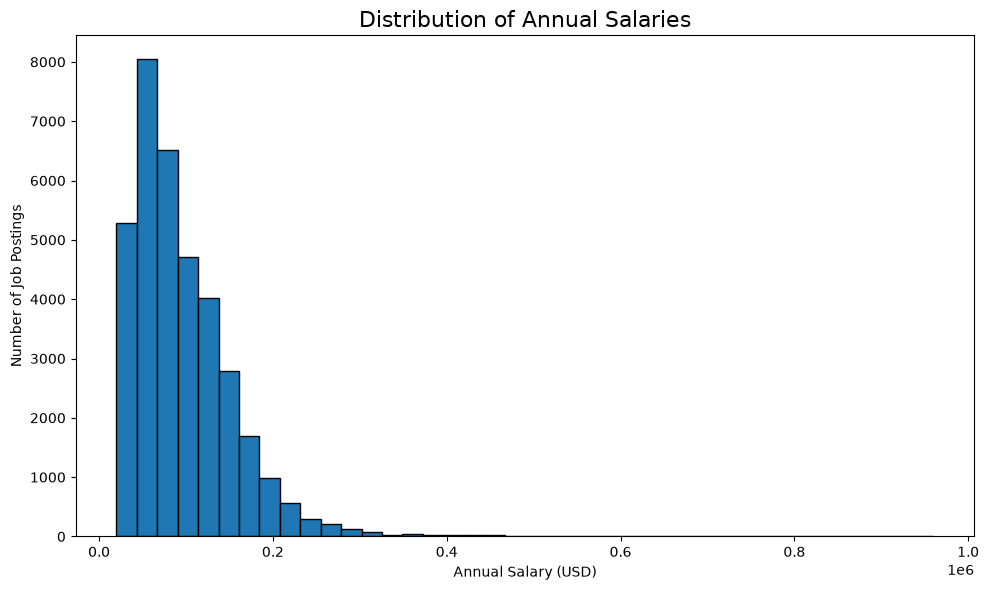

In [10]:
plt.figure(figsize=(10,6))

plt.hist(df["normalized_salary"], bins=50)

plt.title("Distribution of Normalized Salaries")

plt.xlabel("Annual Salary (USD)")

plt.ylabel("Number of Job Postings")

plt.figure(figsize=(10, 6))

plt.hist(
    df["normalized_salary"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Annual Salaries", fontsize=16)
plt.xlabel("Annual Salary (USD)")
plt.ylabel("Number of Job Postings")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of annual salaries is positively (right) skewed, with most job postings concentrated between approximately **$40,000** and **$150,000** per year.

While a relatively small number of jobs offer substantially higher salaries, these observations form a natural upper tail rather than the extreme data quality issues identified during preprocessing.

The skewed distribution suggests that salary is not normally distributed, which is common in labor market data. This observation may influence future feature engineering and model selection.

## Salary by Experience Level

Experience level is expected to be one of the strongest predictors of salary.

To better understand this relationship, I compare the median salary across each experience level.

In [11]:
experience_salary = (
    df.groupby("formatted_experience_level")["normalized_salary"]
      .median()
      .sort_values()
)

experience_salary

formatted_experience_level
Internship           48880.0
Entry level          52500.0
Associate            74994.4
Unknown              78000.0
Mid-Senior level    108200.0
Director            167500.0
Executive           195000.0
Name: normalized_salary, dtype: float64

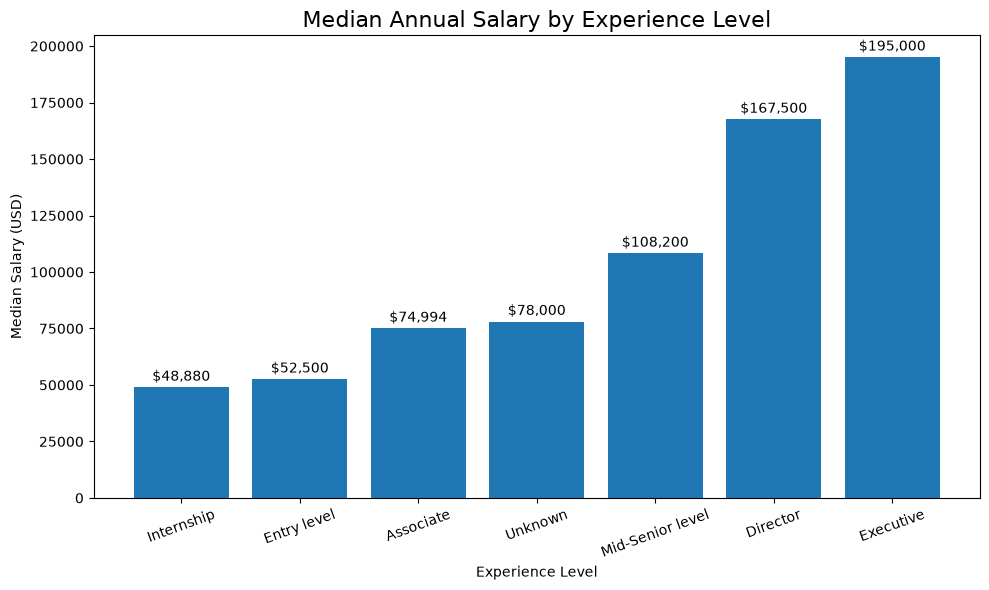

In [12]:
experience_salary = (
    df.groupby("formatted_experience_level")["normalized_salary"]
      .median()
      .sort_values()
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    experience_salary.index,
    experience_salary.values
)

plt.title("Median Annual Salary by Experience Level", fontsize=16)
plt.xlabel("Experience Level")
plt.ylabel("Median Salary (USD)")

plt.xticks(rotation=20)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 3000,
        f"${height:,.0f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Interpretation

A clear positive relationship exists between experience level and annual salary.

Entry-level and internship positions have the lowest median salaries, while director and executive roles earn substantially higher compensation. Mid-senior positions also show a notable increase compared to associate-level roles.

This trend aligns with expectations and suggests that **experience level is likely to be one of the strongest predictive features** in the salary prediction model.

## Salary by Experience Level

After understanding the overall salary distribution, the next step is to examine how salary varies across different experience levels.

If experience level shows a strong relationship with compensation, it is likely to become one of the most important predictive features in the machine learning model. To investigate this relationship, I compare the median annual salary for each experience category.